# Questão 01: Implementação do Algoritmo Perceptron (Manual)

Este notebook implementa o algoritmo Perceptron do zero para resolver as funções lógicas AND, OR e XOR, com visualização do hiperplano durante o treinamento para 2 entradas.

In [12]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import time

# Para plotagem interativa/animada no Jupyter Notebook / VS Code, 
# pode ser necessário executar UMA das seguintes linhas mágicas nesta célula
# e, possivelmente, instalar o pacote ipympl (`pip install ipympl` no seu terminal/ambiente).
# %matplotlib notebook
# %matplotlib ipympl
# Se a animação não funcionar bem na mesma célula, os plots podem aparecer em janelas separadas.

## Funções Auxiliares (Geração de Dados e Plotagem)

In [13]:
def gerar_dados(n_entradas, tipo_funcao='AND'):
    """
    Gera dados para funções lógicas AND, OR, XOR com n_entradas.
    """
    X = np.array(list(product([0, 1], repeat=n_entradas)))
    if tipo_funcao.upper() == 'AND':
        y = np.array([int(np.all(x_i)) for x_i in X])
    elif tipo_funcao.upper() == 'OR':
        y = np.array([int(np.any(x_i)) for x_i in X])
    elif tipo_funcao.upper() == 'XOR':
        if n_entradas != 2:
             print("Atenção: XOR para n!=2 é definido como paridade (soma das entradas % 2 == 1).")
        y = np.array([np.sum(x_i) % 2 for x_i in X]) # Soma par para n entradas
    else:
        raise ValueError("Função lógica inválida. Use 'AND', 'OR' ou 'XOR'.")
    return X, y

def plotar_hiperplano_2d(X, y, perceptron_model, ax, titulo_plot):
    """
    Plota os dados e o hiperplano de separação para n=2 entradas.
    """
    ax.clear()
    
    cores = ['blue', 'red']
    marcadores = ['o', 'x']
    
    if not hasattr(plotar_hiperplano_2d, "_legend_info"):
        plotar_hiperplano_2d._legend_info = {'class0_added': False, 'class1_added': False}
    
    if not ax.collections and not ax.lines: 
        plotar_hiperplano_2d._legend_info['class0_added'] = False
        plotar_hiperplano_2d._legend_info['class1_added'] = False

    for i in range(len(X)):
        current_label = None 
        if y[i] == 0 and not plotar_hiperplano_2d._legend_info['class0_added']:
            current_label = 'Classe 0'
            plotar_hiperplano_2d._legend_info['class0_added'] = True
        elif y[i] == 1 and not plotar_hiperplano_2d._legend_info['class1_added']:
            current_label = 'Classe 1'
            plotar_hiperplano_2d._legend_info['class1_added'] = True
            
        ax.scatter(X[i, 0], X[i, 1], color=cores[y[i]], marker=marcadores[y[i]], s=100, edgecolors='k', label=current_label)

    w = perceptron_model.pesos
    if w is not None and len(w) == 3: 
        x_data_min_plot, x_data_max_plot = -0.5, 1.5 
        y_data_min_plot, y_data_max_plot = -0.5, 1.5
        
        line_x_coords = np.array([x_data_min_plot, x_data_max_plot])
        
        if abs(w[2]) > 1e-5: 
            line_y_coords = (-w[1] * line_x_coords - w[0]) / w[2]
            ax.plot(line_x_coords, line_y_coords, '--', color='green', linewidth=2)
        elif abs(w[1]) > 1e-5: 
            x_vert_coord = -w[0] / w[1]
            ax.plot([x_vert_coord, x_vert_coord], [y_data_min_plot, y_data_max_plot], '--', color='green', linewidth=2)

    ax.set_title(titulo_plot, fontsize=14)
    ax.set_xlabel("Entrada x1", fontsize=12)
    ax.set_ylabel("Entrada x2", fontsize=12)
    ax.set_xlim([x_data_min_plot, x_data_max_plot])
    ax.set_ylim([y_data_min_plot, y_data_max_plot])
    ax.grid(True, linestyle=':', alpha=0.7)
    
    handles, labels = ax.get_legend_handles_labels()
    if any(labels): 
        ax.legend(loc='best', fontsize=10)
    
    if hasattr(ax.figure, 'canvas') and ax.figure.canvas is not None:
        ax.figure.canvas.draw_idle()
    time.sleep(0.1) 

def plotar_curva_erro(erros_por_epoca, titulo_plot):
    fig_erro, ax_erro = plt.subplots(figsize=(7,5)) 
    ax_erro.plot(range(1, len(erros_por_epoca) + 1), erros_por_epoca, marker='o', linestyle='-', color='purple')
    ax_erro.set_xlabel('Época', fontsize=12)
    ax_erro.set_ylabel('Número de Erros de Classificação', fontsize=12)
    ax_erro.set_title(titulo_plot, fontsize=14)
    ax_erro.grid(True, linestyle=':', alpha=0.7)
    plt.show()

## Classe Perceptron

In [14]:
class Perceptron:
    def __init__(self, taxa_aprendizado=0.1, n_epocas=100):
        self.taxa_aprendizado = taxa_aprendizado
        self.n_epocas = n_epocas
        self.pesos = None
        self.erros_por_epoca = []

    def _adicionar_bias_input(self, X_i):
        # Adiciona o valor 1 no início de X_i para o bias (peso w0)
        return np.insert(X_i, 0, 1)

    def predict(self, X_i_com_bias):
        # Calcula a soma ponderada
        z = np.dot(X_i_com_bias, self.pesos)
        # Função de ativação degrau
        return 1 if z >= 0 else 0

    def fit(self, X, y, ax_plot=None, X_original_plot=None, y_original_plot=None, plot_interval=1, title_suffix=""):
        n_amostras, n_caracteristicas = X.shape
        # Inicializa os pesos: n_caracteristicas + 1 (para o bias w0)
        self.pesos = np.random.rand(n_caracteristicas + 1) * 0.1 - 0.05 # Pequenos valores aleatórios
        self.erros_por_epoca = []
        X_com_bias = np.insert(X, 0, 1, axis=1)

        convergiu = False
        for epoca in range(self.n_epocas):
            erros_epoca_atual = 0
            for i in range(n_amostras):
                X_i_com_bias = X_com_bias[i]
                y_i_real = y[i]
                y_predito = self.predict(X_i_com_bias)
                erro = y_i_real - y_predito

                if erro != 0:
                    erros_epoca_atual += 1
                    # Atualiza os pesos
                    self.pesos += self.taxa_aprendizado * erro * X_i_com_bias
            
            self.erros_por_epoca.append(erros_epoca_atual)

            # Plotagem durante o treinamento (apenas se ax_plot for fornecido, i.e., n_entradas == 2)
            if ax_plot and X_original_plot is not None and y_original_plot is not None:
                if (epoca + 1) % plot_interval == 0 or (erros_epoca_atual == 0 and epoca > 0):
                    plotar_hiperplano_2d(X_original_plot, y_original_plot, self, ax_plot, f"Época: {epoca + 1}{title_suffix}") # Chamada aqui
                    if erros_epoca_atual == 0 and epoca > 0: 
                        print(f"Convergência alcançada na época {epoca + 1}.")
                        convergiu = True
                        break 
            
            if erros_epoca_atual == 0 and epoca > 0: 
                if not ax_plot: 
                     print(f"Convergência alcançada na época {epoca + 1}.")
                convergiu = True
                break
        
        # Mensagem final sobre convergência
        if convergiu and ax_plot and X_original_plot is not None and y_original_plot is not None and self.erros_por_epoca[-1] == 0: 
            plotar_hiperplano_2d(X_original_plot, y_original_plot, self, ax_plot, f"Convergência Final - Época: {len(self.erros_por_epoca)}{title_suffix}") # Chamada aqui
        elif not convergiu and len(self.erros_por_epoca) > 0 and self.erros_por_epoca[-1] !=0 :
            print(f"Não convergiu após {len(self.erros_por_epoca)} épocas. Erros na última época: {self.erros_por_epoca[-1]}")

## Demonstração: Perceptron para XOR com 2 entradas

Primeiro, demonstramos a incapacidade do Perceptron de uma única camada em resolver o problema XOR, que não é linearmente separável.
A plotagem do hiperplano será animada durante o treinamento.

--- Demonstração: Perceptron para XOR com 2 entradas ---
Plotando hiperplano para XOR durante o treinamento (n=2)...


C:\Users\Luan\AppData\Local\Temp\ipykernel_19048\4162445670.py:43: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X[i, 0], X[i, 1], color=cores[y[i]], marker=marcadores[y[i]], s=100, edgecolors='k', label=current_label)


Não convergiu após 50 épocas. Erros na última época: 4

Pesos finais para XOR: [ 0.04978103 -0.07370537  0.02948319]
Predições finais para XOR:
Entrada: [0 0], Saída Esperada: 0, Saída Predita: 1
Entrada: [0 1], Saída Esperada: 1, Saída Predita: 1
Entrada: [1 0], Saída Esperada: 1, Saída Predita: 0
Entrada: [1 1], Saída Esperada: 0, Saída Predita: 1
Acurácia final para XOR: 25.00%


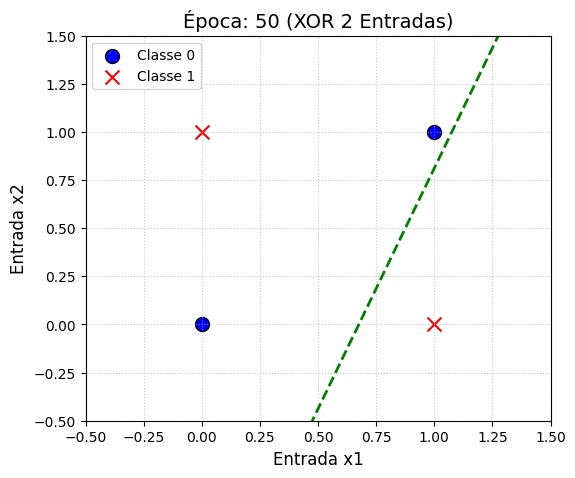

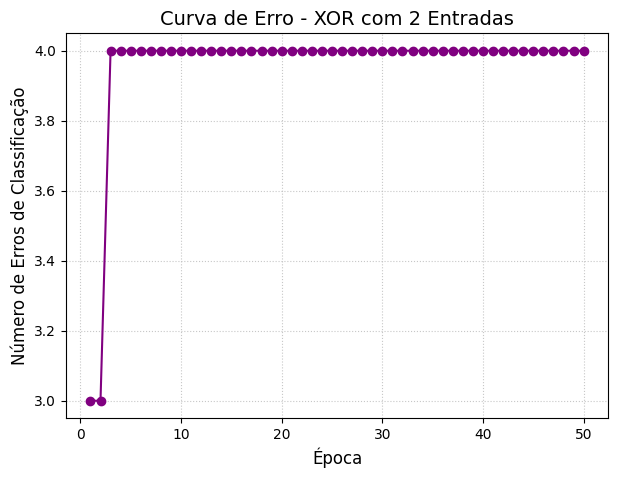


Observe a curva de erro do XOR e o hiperplano que não consegue separar as classes.


In [15]:
print("--- Demonstração: Perceptron para XOR com 2 entradas ---")
X_xor, y_xor = gerar_dados(n_entradas=2, tipo_funcao='XOR')
perceptron_xor = Perceptron(taxa_aprendizado=0.1, n_epocas=50)

fig_xor_anim, ax_xor_anim = plt.subplots(figsize=(6,5))
print("Plotando hiperplano para XOR durante o treinamento (n=2)...")

try:
    perceptron_xor.fit(X_xor, y_xor, ax_xor_anim, X_xor, y_xor, plot_interval=1, title_suffix=" (XOR 2 Entradas)")
    if fig_xor_anim.canvas: 
        fig_xor_anim.canvas.draw_idle()
        fig_xor_anim.canvas.flush_events()
except Exception as e:
    print(f"Erro durante a plotagem animada: {e}")

print("\nPesos finais para XOR:", perceptron_xor.pesos)
print("Predições finais para XOR:")
acertos_xor = 0
if len(X_xor) > 0:
    for i in range(len(X_xor)):
        entrada_com_bias = perceptron_xor._adicionar_bias_input(X_xor[i])
        predicao = perceptron_xor.predict(entrada_com_bias)
        if predicao == y_xor[i]:
            acertos_xor +=1
        print(f"Entrada: {X_xor[i]}, Saída Esperada: {y_xor[i]}, Saída Predita: {predicao}")
    print(f"Acurácia final para XOR: {acertos_xor/len(X_xor)*100:.2f}%")

plotar_curva_erro(perceptron_xor.erros_por_epoca, "Curva de Erro - XOR com 2 Entradas")
print("\nObserve a curva de erro do XOR e o hiperplano que não consegue separar as classes.")
plt.show()

## Testes com AND e OR (Entrada do Usuário)

Agora, o usuário pode escolher a função (AND ou OR) e o número de entradas.
- Se `n_entradas = 2`, o hiperplano será plotado dinamicamente durante o treinamento.
- Se `n_entradas > 2`, apenas a curva de erro será plotada ao final.


--- Configuração do Usuário ---

--- Testando Perceptron para AND com 2 entradas ---
Plotando hiperplano durante o treinamento (n=2)...


C:\Users\Luan\AppData\Local\Temp\ipykernel_19048\4162445670.py:43: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X[i, 0], X[i, 1], color=cores[y[i]], marker=marcadores[y[i]], s=100, edgecolors='k', label=current_label)


Convergência alcançada na época 2.

Pesos finais para AND com 2 entradas: [-0.04310269  0.01674753  0.03098974]
Predições finais para AND com 2 entradas (primeiras e últimas 3 amostras se houver muitas):
Entrada: [0 0], Saída Esperada: 0, Saída Predita: 0
Entrada: [0 1], Saída Esperada: 0, Saída Predita: 0
Entrada: [1 0], Saída Esperada: 0, Saída Predita: 0
Entrada: [1 1], Saída Esperada: 1, Saída Predita: 1
Acurácia final para AND com 2 entradas: 100.00%


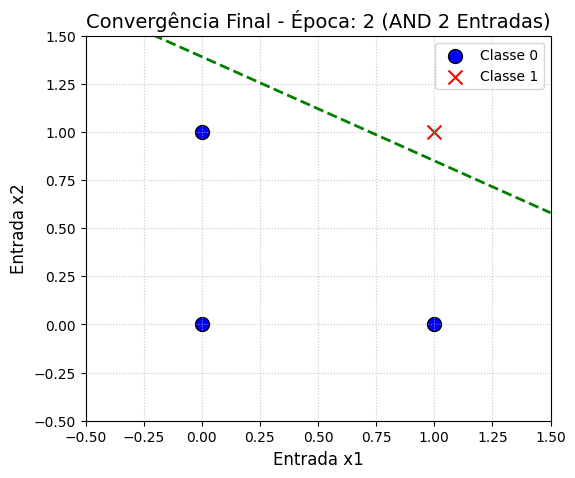

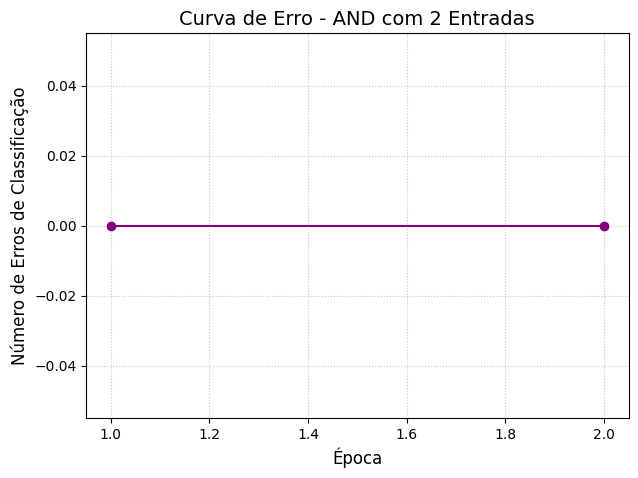


Fim dos testes.


In [17]:
# --- Entrada do Usuário para AND ou OR ---
tipo_func_usr_input = ""
num_entradas_usr_input = 0

while True:
    try:
        print("\n--- Configuração do Usuário ---")
        tipo_func_usr_input = input("Digite a função lógica (AND ou OR): ").upper()
        if tipo_func_usr_input not in ['AND', 'OR']:
            raise ValueError("Função inválida.")
        
        num_entradas_usr_input = int(input(f"Digite o número de entradas para {tipo_func_usr_input} (ex: 2, 3, 10): "))
        if num_entradas_usr_input < 1: 
            raise ValueError("Número de entradas deve ser pelo menos 1.")
        break
    except ValueError as e:
        print(f"Erro: {e} Tente novamente.")

X_usr, y_usr = gerar_dados(n_entradas=num_entradas_usr_input, tipo_funcao=tipo_func_usr_input)
perceptron_usr = Perceptron(taxa_aprendizado=0.1, n_epocas=100 if num_entradas_usr_input <=3 else 200) 

print(f"\n--- Testando Perceptron para {tipo_func_usr_input} com {num_entradas_usr_input} entradas ---")

ax_plot_usr = None 
fig_anim_usr = None

if num_entradas_usr_input == 2:
    print("Plotando hiperplano durante o treinamento (n=2)...")
    fig_anim_usr, ax_plot_usr = plt.subplots(figsize=(6,5))
    try:
        perceptron_usr.fit(X_usr, y_usr, ax_plot_usr, X_usr, y_usr, plot_interval=1, title_suffix=f" ({tipo_func_usr_input} {num_entradas_usr_input} Entradas)")
        if fig_anim_usr.canvas: 
            fig_anim_usr.canvas.draw_idle()
            fig_anim_usr.canvas.flush_events()
    except Exception as e:
        print(f"Erro durante a plotagem animada: {e}")
else:
    print(f"Para n={num_entradas_usr_input} entradas, o hiperplano 2D não será plotado dinamicamente.")
    print("Treinando o Perceptron...")
    perceptron_usr.fit(X_usr, y_usr) 

print(f"\nPesos finais para {tipo_func_usr_input} com {num_entradas_usr_input} entradas:", perceptron_usr.pesos)
print(f"Predições finais para {tipo_func_usr_input} com {num_entradas_usr_input} entradas (primeiras e últimas 3 amostras se houver muitas):")

acertos_usr = 0
amostras_a_mostrar_indices = []
if len(X_usr) == 0:
    print("Nenhum dado gerado.")
elif len(X_usr) <= 6:
    amostras_a_mostrar_indices = range(len(X_usr))
else:
    amostras_a_mostrar_indices = list(range(3)) + list(range(len(X_usr) - 3, len(X_usr)))

for i in amostras_a_mostrar_indices:
    if i < len(X_usr): 
        entrada_com_bias = perceptron_usr._adicionar_bias_input(X_usr[i])
        predicao = perceptron_usr.predict(entrada_com_bias)
        if predicao == y_usr[i]:
            acertos_usr +=1
        print(f"Entrada: {X_usr[i]}, Saída Esperada: {y_usr[i]}, Saída Predita: {predicao}")

if len(X_usr) > 0: 
    print(f"Acurácia final para {tipo_func_usr_input} com {num_entradas_usr_input} entradas: {acertos_usr/len(X_usr)*100:.2f}%")

plotar_curva_erro(perceptron_usr.erros_por_epoca, f"Curva de Erro - {tipo_func_usr_input} com {num_entradas_usr_input} Entradas")

print("\nFim dos testes.")
plt.show()


--- Configuração do Usuário ---

--- Testando Perceptron para AND com 3 entradas ---
Para n=3 entradas, o hiperplano 2D não será plotado dinamicamente.
Treinando o Perceptron...
Convergência alcançada na época 7.

Pesos finais para AND com 3 entradas: [-0.40746623  0.23167098  0.12058812  0.14178248]
Predições finais para AND com 3 entradas (primeiras e últimas 3 amostras se houver muitas):
Entrada: [0 0 0], Saída Esperada: 0, Saída Predita: 0
Entrada: [0 0 1], Saída Esperada: 0, Saída Predita: 0
Entrada: [0 1 0], Saída Esperada: 0, Saída Predita: 0
Entrada: [1 0 1], Saída Esperada: 0, Saída Predita: 0
Entrada: [1 1 0], Saída Esperada: 0, Saída Predita: 0
Entrada: [1 1 1], Saída Esperada: 1, Saída Predita: 1
Acurácia final para AND com 3 entradas: 75.00%


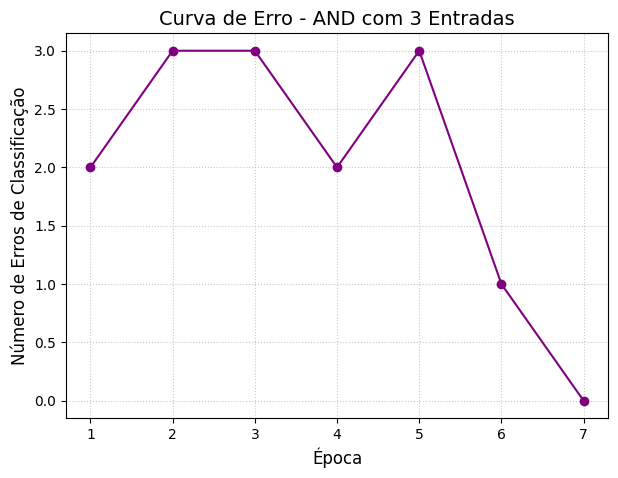


Fim dos testes.


In [18]:
# --- Entrada do Usuário para AND ou OR ---
tipo_func_usr_input = ""
num_entradas_usr_input = 0

while True:
    try:
        print("\n--- Configuração do Usuário ---")
        tipo_func_usr_input = input("Digite a função lógica (AND ou OR): ").upper()
        if tipo_func_usr_input not in ['AND', 'OR']:
            raise ValueError("Função inválida.")
        
        num_entradas_usr_input = int(input(f"Digite o número de entradas para {tipo_func_usr_input} (ex: 2, 3, 10): "))
        if num_entradas_usr_input < 1: 
            raise ValueError("Número de entradas deve ser pelo menos 1.")
        break
    except ValueError as e:
        print(f"Erro: {e} Tente novamente.")

X_usr, y_usr = gerar_dados(n_entradas=num_entradas_usr_input, tipo_funcao=tipo_func_usr_input)
perceptron_usr = Perceptron(taxa_aprendizado=0.1, n_epocas=100 if num_entradas_usr_input <=3 else 200) 

print(f"\n--- Testando Perceptron para {tipo_func_usr_input} com {num_entradas_usr_input} entradas ---")

ax_plot_usr = None 
fig_anim_usr = None

if num_entradas_usr_input == 2:
    print("Plotando hiperplano durante o treinamento (n=2)...")
    fig_anim_usr, ax_plot_usr = plt.subplots(figsize=(6,5))
    try:
        perceptron_usr.fit(X_usr, y_usr, ax_plot_usr, X_usr, y_usr, plot_interval=1, title_suffix=f" ({tipo_func_usr_input} {num_entradas_usr_input} Entradas)")
        if fig_anim_usr.canvas: 
            fig_anim_usr.canvas.draw_idle()
            fig_anim_usr.canvas.flush_events()
    except Exception as e:
        print(f"Erro durante a plotagem animada: {e}")
else:
    print(f"Para n={num_entradas_usr_input} entradas, o hiperplano 2D não será plotado dinamicamente.")
    print("Treinando o Perceptron...")
    perceptron_usr.fit(X_usr, y_usr) 

print(f"\nPesos finais para {tipo_func_usr_input} com {num_entradas_usr_input} entradas:", perceptron_usr.pesos)
print(f"Predições finais para {tipo_func_usr_input} com {num_entradas_usr_input} entradas (primeiras e últimas 3 amostras se houver muitas):")

acertos_usr = 0
amostras_a_mostrar_indices = []
if len(X_usr) == 0:
    print("Nenhum dado gerado.")
elif len(X_usr) <= 6:
    amostras_a_mostrar_indices = range(len(X_usr))
else:
    amostras_a_mostrar_indices = list(range(3)) + list(range(len(X_usr) - 3, len(X_usr)))

for i in amostras_a_mostrar_indices:
    if i < len(X_usr): 
        entrada_com_bias = perceptron_usr._adicionar_bias_input(X_usr[i])
        predicao = perceptron_usr.predict(entrada_com_bias)
        if predicao == y_usr[i]:
            acertos_usr +=1
        print(f"Entrada: {X_usr[i]}, Saída Esperada: {y_usr[i]}, Saída Predita: {predicao}")

if len(X_usr) > 0: 
    print(f"Acurácia final para {tipo_func_usr_input} com {num_entradas_usr_input} entradas: {acertos_usr/len(X_usr)*100:.2f}%")

plotar_curva_erro(perceptron_usr.erros_por_epoca, f"Curva de Erro - {tipo_func_usr_input} com {num_entradas_usr_input} Entradas")

print("\nFim dos testes.")
plt.show()


--- Configuração do Usuário ---

--- Testando Perceptron para AND com 10 entradas ---
Para n=10 entradas, o hiperplano 2D não será plotado dinamicamente.
Treinando o Perceptron...
Não convergiu após 200 épocas. Erros na última época: 2

Pesos finais para AND com 10 entradas: [-4.67689789  1.00052922  0.91265618  0.84844958  0.67558875  0.64311098
  0.59960131  0.18433527  0.20461409  0.17263631  0.10967702]
Predições finais para AND com 10 entradas (primeiras e últimas 3 amostras se houver muitas):
Entrada: [0 0 0 0 0 0 0 0 0 0], Saída Esperada: 0, Saída Predita: 0
Entrada: [0 0 0 0 0 0 0 0 0 1], Saída Esperada: 0, Saída Predita: 0
Entrada: [0 0 0 0 0 0 0 0 1 0], Saída Esperada: 0, Saída Predita: 0
Entrada: [1 1 1 1 1 1 1 1 0 1], Saída Esperada: 0, Saída Predita: 1
Entrada: [1 1 1 1 1 1 1 1 1 0], Saída Esperada: 0, Saída Predita: 1
Entrada: [1 1 1 1 1 1 1 1 1 1], Saída Esperada: 1, Saída Predita: 1
Acurácia final para AND com 10 entradas: 0.39%


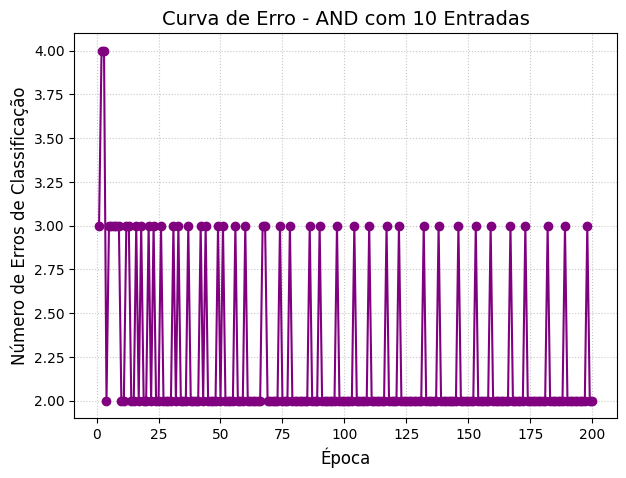


Fim dos testes.


In [19]:
# --- Entrada do Usuário para AND ou OR ---
tipo_func_usr_input = ""
num_entradas_usr_input = 0

while True:
    try:
        print("\n--- Configuração do Usuário ---")
        tipo_func_usr_input = input("Digite a função lógica (AND ou OR): ").upper()
        if tipo_func_usr_input not in ['AND', 'OR']:
            raise ValueError("Função inválida.")
        
        num_entradas_usr_input = int(input(f"Digite o número de entradas para {tipo_func_usr_input} (ex: 2, 3, 10): "))
        if num_entradas_usr_input < 1: 
            raise ValueError("Número de entradas deve ser pelo menos 1.")
        break
    except ValueError as e:
        print(f"Erro: {e} Tente novamente.")

X_usr, y_usr = gerar_dados(n_entradas=num_entradas_usr_input, tipo_funcao=tipo_func_usr_input)
perceptron_usr = Perceptron(taxa_aprendizado=0.1, n_epocas=100 if num_entradas_usr_input <=3 else 200) 

print(f"\n--- Testando Perceptron para {tipo_func_usr_input} com {num_entradas_usr_input} entradas ---")

ax_plot_usr = None 
fig_anim_usr = None

if num_entradas_usr_input == 2:
    print("Plotando hiperplano durante o treinamento (n=2)...")
    fig_anim_usr, ax_plot_usr = plt.subplots(figsize=(6,5))
    try:
        perceptron_usr.fit(X_usr, y_usr, ax_plot_usr, X_usr, y_usr, plot_interval=1, title_suffix=f" ({tipo_func_usr_input} {num_entradas_usr_input} Entradas)")
        if fig_anim_usr.canvas: 
            fig_anim_usr.canvas.draw_idle()
            fig_anim_usr.canvas.flush_events()
    except Exception as e:
        print(f"Erro durante a plotagem animada: {e}")
else:
    print(f"Para n={num_entradas_usr_input} entradas, o hiperplano 2D não será plotado dinamicamente.")
    print("Treinando o Perceptron...")
    perceptron_usr.fit(X_usr, y_usr) 

print(f"\nPesos finais para {tipo_func_usr_input} com {num_entradas_usr_input} entradas:", perceptron_usr.pesos)
print(f"Predições finais para {tipo_func_usr_input} com {num_entradas_usr_input} entradas (primeiras e últimas 3 amostras se houver muitas):")

acertos_usr = 0
amostras_a_mostrar_indices = []
if len(X_usr) == 0:
    print("Nenhum dado gerado.")
elif len(X_usr) <= 6:
    amostras_a_mostrar_indices = range(len(X_usr))
else:
    amostras_a_mostrar_indices = list(range(3)) + list(range(len(X_usr) - 3, len(X_usr)))

for i in amostras_a_mostrar_indices:
    if i < len(X_usr): 
        entrada_com_bias = perceptron_usr._adicionar_bias_input(X_usr[i])
        predicao = perceptron_usr.predict(entrada_com_bias)
        if predicao == y_usr[i]:
            acertos_usr +=1
        print(f"Entrada: {X_usr[i]}, Saída Esperada: {y_usr[i]}, Saída Predita: {predicao}")

if len(X_usr) > 0: 
    print(f"Acurácia final para {tipo_func_usr_input} com {num_entradas_usr_input} entradas: {acertos_usr/len(X_usr)*100:.2f}%")

plotar_curva_erro(perceptron_usr.erros_por_epoca, f"Curva de Erro - {tipo_func_usr_input} com {num_entradas_usr_input} Entradas")

print("\nFim dos testes.")
plt.show()


--- Configuração do Usuário ---

--- Testando Perceptron para OR com 2 entradas ---
Plotando hiperplano durante o treinamento (n=2)...


C:\Users\Luan\AppData\Local\Temp\ipykernel_19048\4162445670.py:43: UserWarning: You passed a edgecolor/edgecolors ('k') for an unfilled marker ('x').  Matplotlib is ignoring the edgecolor in favor of the facecolor.  This behavior may change in the future.
  ax.scatter(X[i, 0], X[i, 1], color=cores[y[i]], marker=marcadores[y[i]], s=100, edgecolors='k', label=current_label)


Convergência alcançada na época 4.

Pesos finais para OR com 2 entradas: [-0.02119972  0.07048892  0.07895236]
Predições finais para OR com 2 entradas (primeiras e últimas 3 amostras se houver muitas):
Entrada: [0 0], Saída Esperada: 0, Saída Predita: 0
Entrada: [0 1], Saída Esperada: 1, Saída Predita: 1
Entrada: [1 0], Saída Esperada: 1, Saída Predita: 1
Entrada: [1 1], Saída Esperada: 1, Saída Predita: 1
Acurácia final para OR com 2 entradas: 100.00%


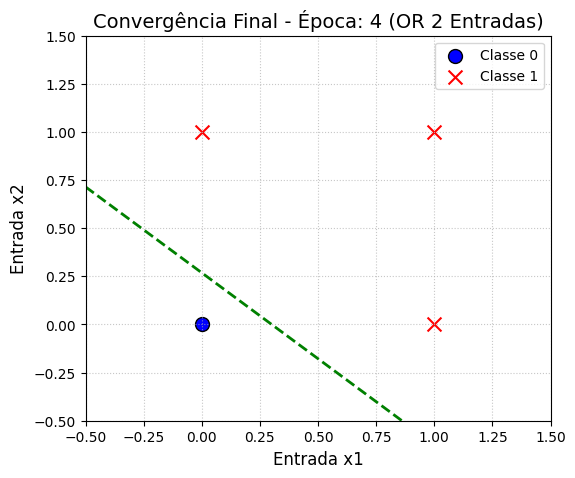

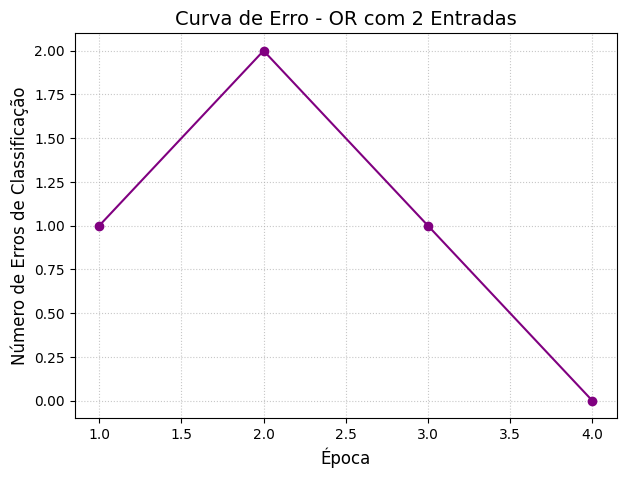


Fim dos testes.


In [20]:
# --- Entrada do Usuário para AND ou OR ---
tipo_func_usr_input = ""
num_entradas_usr_input = 0

while True:
    try:
        print("\n--- Configuração do Usuário ---")
        tipo_func_usr_input = input("Digite a função lógica (AND ou OR): ").upper()
        if tipo_func_usr_input not in ['AND', 'OR']:
            raise ValueError("Função inválida.")
        
        num_entradas_usr_input = int(input(f"Digite o número de entradas para {tipo_func_usr_input} (ex: 2, 3, 10): "))
        if num_entradas_usr_input < 1: 
            raise ValueError("Número de entradas deve ser pelo menos 1.")
        break
    except ValueError as e:
        print(f"Erro: {e} Tente novamente.")

X_usr, y_usr = gerar_dados(n_entradas=num_entradas_usr_input, tipo_funcao=tipo_func_usr_input)
perceptron_usr = Perceptron(taxa_aprendizado=0.1, n_epocas=100 if num_entradas_usr_input <=3 else 200) 

print(f"\n--- Testando Perceptron para {tipo_func_usr_input} com {num_entradas_usr_input} entradas ---")

ax_plot_usr = None 
fig_anim_usr = None

if num_entradas_usr_input == 2:
    print("Plotando hiperplano durante o treinamento (n=2)...")
    fig_anim_usr, ax_plot_usr = plt.subplots(figsize=(6,5))
    try:
        perceptron_usr.fit(X_usr, y_usr, ax_plot_usr, X_usr, y_usr, plot_interval=1, title_suffix=f" ({tipo_func_usr_input} {num_entradas_usr_input} Entradas)")
        if fig_anim_usr.canvas: 
            fig_anim_usr.canvas.draw_idle()
            fig_anim_usr.canvas.flush_events()
    except Exception as e:
        print(f"Erro durante a plotagem animada: {e}")
else:
    print(f"Para n={num_entradas_usr_input} entradas, o hiperplano 2D não será plotado dinamicamente.")
    print("Treinando o Perceptron...")
    perceptron_usr.fit(X_usr, y_usr) 

print(f"\nPesos finais para {tipo_func_usr_input} com {num_entradas_usr_input} entradas:", perceptron_usr.pesos)
print(f"Predições finais para {tipo_func_usr_input} com {num_entradas_usr_input} entradas (primeiras e últimas 3 amostras se houver muitas):")

acertos_usr = 0
amostras_a_mostrar_indices = []
if len(X_usr) == 0:
    print("Nenhum dado gerado.")
elif len(X_usr) <= 6:
    amostras_a_mostrar_indices = range(len(X_usr))
else:
    amostras_a_mostrar_indices = list(range(3)) + list(range(len(X_usr) - 3, len(X_usr)))

for i in amostras_a_mostrar_indices:
    if i < len(X_usr): 
        entrada_com_bias = perceptron_usr._adicionar_bias_input(X_usr[i])
        predicao = perceptron_usr.predict(entrada_com_bias)
        if predicao == y_usr[i]:
            acertos_usr +=1
        print(f"Entrada: {X_usr[i]}, Saída Esperada: {y_usr[i]}, Saída Predita: {predicao}")

if len(X_usr) > 0: 
    print(f"Acurácia final para {tipo_func_usr_input} com {num_entradas_usr_input} entradas: {acertos_usr/len(X_usr)*100:.2f}%")

plotar_curva_erro(perceptron_usr.erros_por_epoca, f"Curva de Erro - {tipo_func_usr_input} com {num_entradas_usr_input} Entradas")

print("\nFim dos testes.")
plt.show()